## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder
)

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif
)

# PCA
from sklearn.decomposition import PCA

# Train Test Split
from sklearn.model_selection import train_test_split

# Gaussian Test
from scipy.stats import shapiro

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Load DataSet

In [ ]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Data-Preprocessing

In [ ]:
print(df.shape) #Tells us about the number of rows and columns
print(df.info())  #Tells us about each col datatypes and null values
print(df.describe()) #Tells us about the min, max, mean, etc for each column

(20640, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.0000

In [ ]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


No duplicate Values

In [ ]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


No Null values

In [ ]:
numerical_cols = []
categorical_cols = []

for col in df.columns:

    # Ignore target column if needed
    # if col == 'survived':
    #     continue

    # Check categorical/object/category datatype
    if (
        df[col].dtype == 'object' or
        str(df[col].dtype) == 'category'
    ):
        categorical_cols.append(col)

    else:
        numerical_cols.append(col)

print("numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

numerical Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Categorical Columns:
[]


All columns are numerical

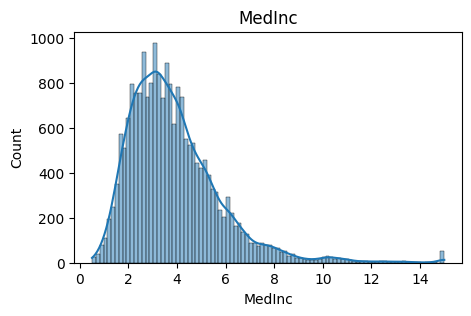

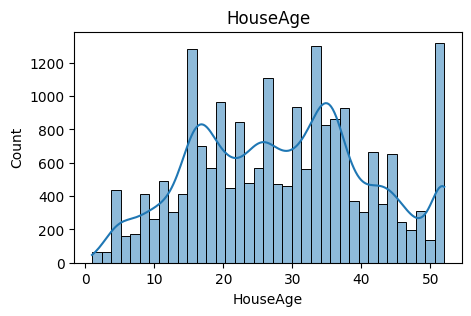

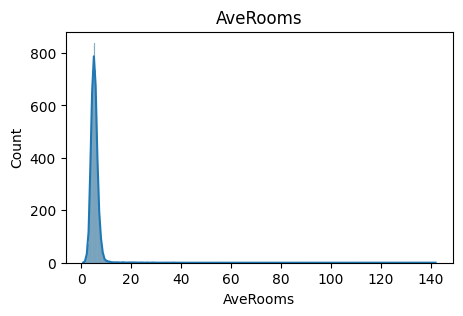

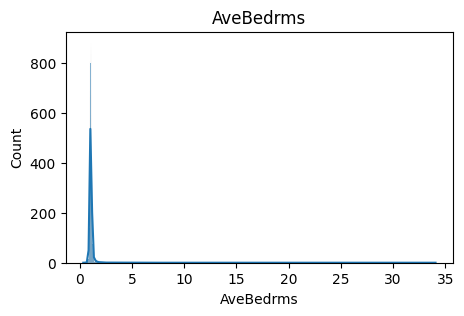

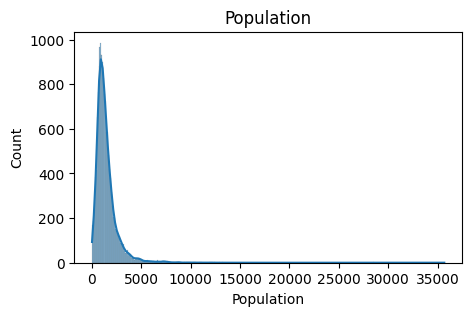

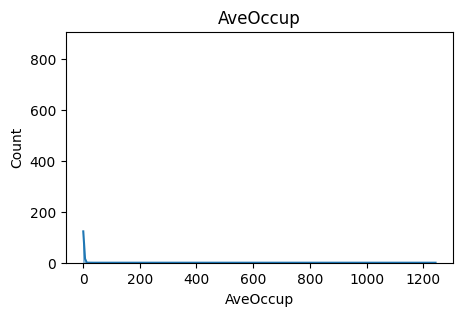

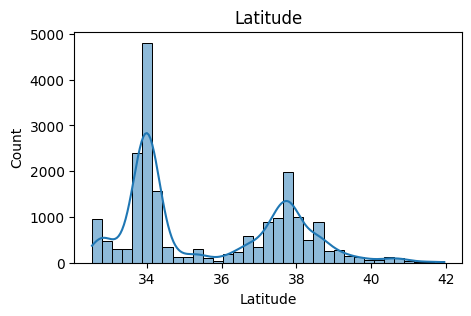

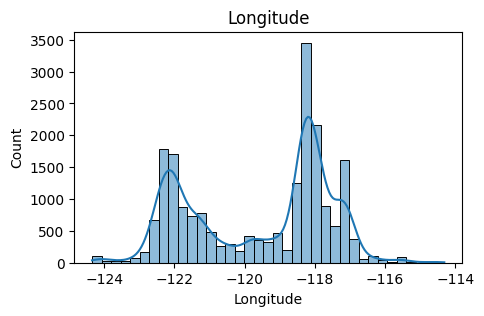

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

MedInc is gaussian rest are not

In [ ]:
import pandas as pd
import numpy as np

print("OUTLIER DETECTION USING IQR\n")

for col in df.columns:

    # Skip categorical/object/category columns
    if (
        df[col].dtype == 'object' or
        str(df[col].dtype) == 'category' or
        df[col].dtype == 'bool'
    ):
        continue

    # Skip binary/ordinal categorical features
    if col in ['survived', 'pclass']:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"Column : {col}")
    print(f"Skewness : {round(df[col].skew(), 3)}")
    print(f"Lower Bound : {round(lower_bound, 3)}")
    print(f"Upper Bound : {round(upper_bound, 3)}")
    print(f"Outliers : {outliers.shape[0]}")
    print("-" * 50)

OUTLIER DETECTION USING IQR

Column : MedInc
Skewness : 1.647
Lower Bound : -0.706
Upper Bound : 8.013
Outliers : 681
--------------------------------------------------
Column : HouseAge
Skewness : 0.06
Lower Bound : -10.5
Upper Bound : 65.5
Outliers : 0
--------------------------------------------------
Column : AveRooms
Skewness : 20.698
Lower Bound : 2.023
Upper Bound : 8.47
Outliers : 511
--------------------------------------------------
Column : AveBedrms
Skewness : 31.317
Lower Bound : 0.866
Upper Bound : 1.24
Outliers : 1424
--------------------------------------------------
Column : Population
Skewness : 4.936
Lower Bound : -620.0
Upper Bound : 3132.0
Outliers : 1196
--------------------------------------------------
Column : AveOccup
Skewness : 97.64
Lower Bound : 1.151
Upper Bound : 4.561
Outliers : 711
--------------------------------------------------
Column : Latitude
Skewness : 0.466
Lower Bound : 28.26
Upper Bound : 43.38
Outliers : 0
-----------------------------------


Column : MedInc
Skewness : 1.647
Outliers : 681
Recommended Scaling : RobustScaler


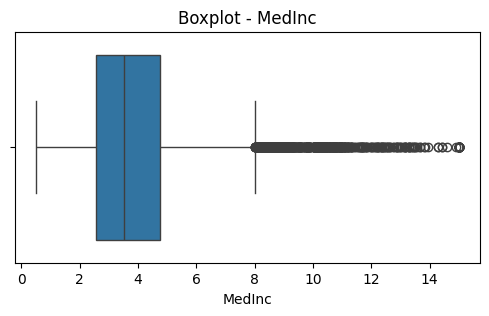

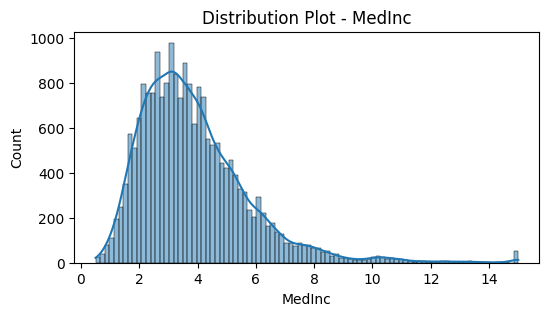


Column : HouseAge
Skewness : 0.06
Outliers : 0
Recommended Scaling : StandardScaler


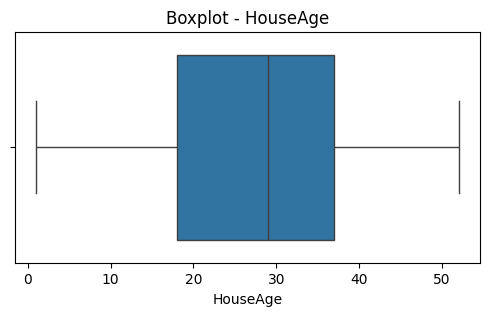

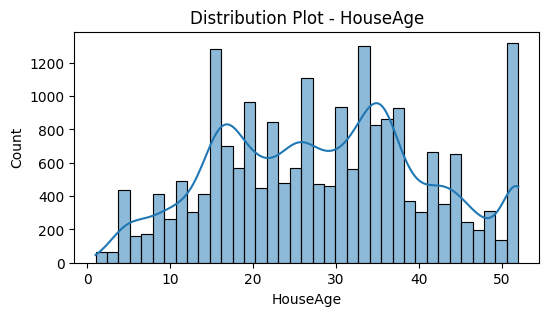


Column : AveRooms
Skewness : 20.698
Outliers : 511
Recommended Scaling : RobustScaler


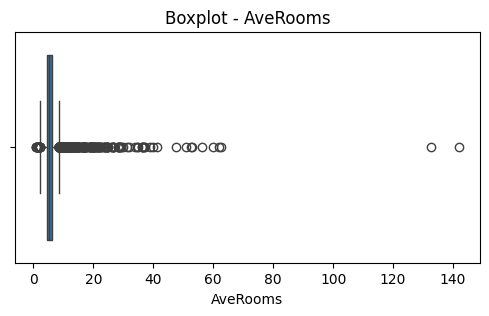

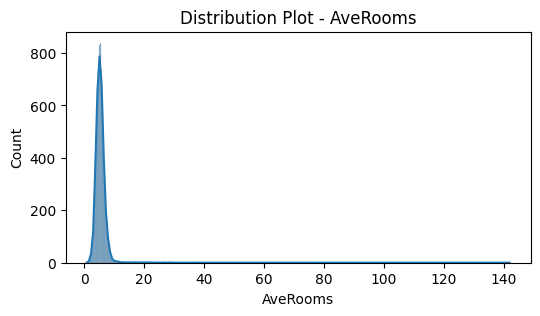


Column : AveBedrms
Skewness : 31.317
Outliers : 1424
Recommended Scaling : RobustScaler


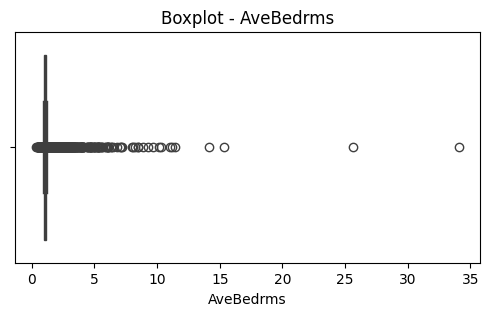

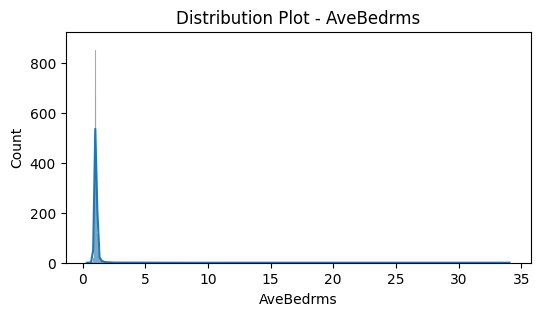


Column : Population
Skewness : 4.936
Outliers : 1196
Recommended Scaling : RobustScaler


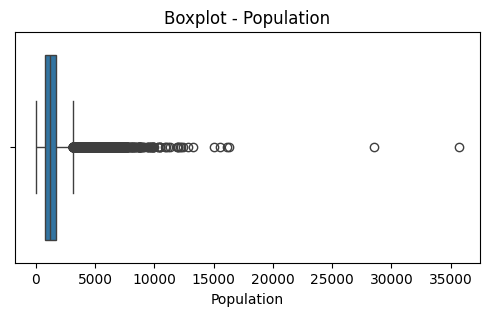

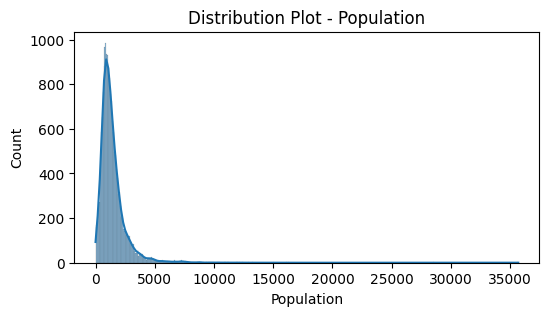


Column : AveOccup
Skewness : 97.64
Outliers : 711
Recommended Scaling : RobustScaler


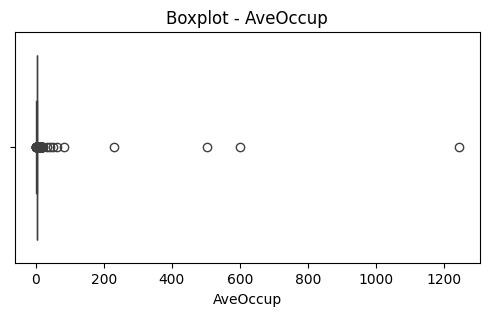

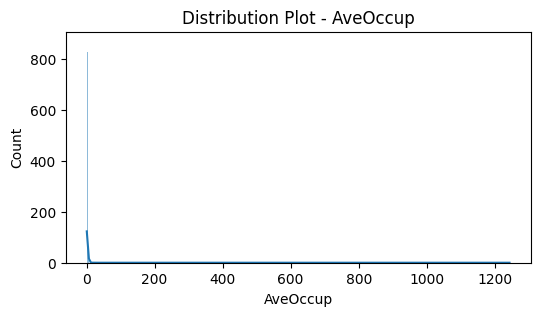


Column : Latitude
Skewness : 0.466
Outliers : 0
Recommended Scaling : StandardScaler


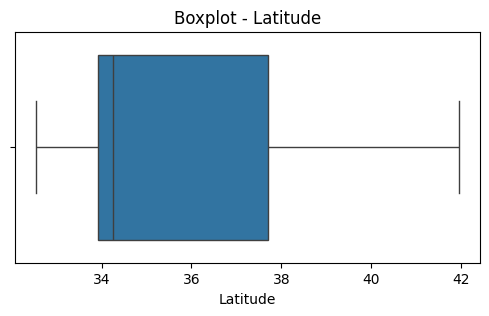

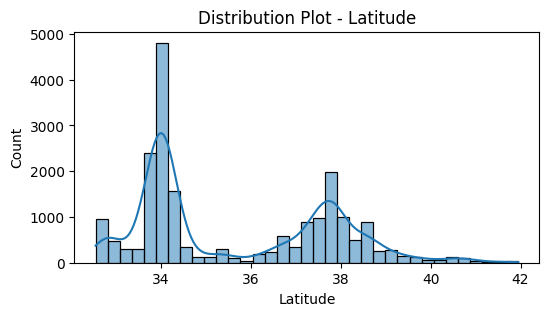


Column : Longitude
Skewness : -0.298
Outliers : 0
Recommended Scaling : StandardScaler


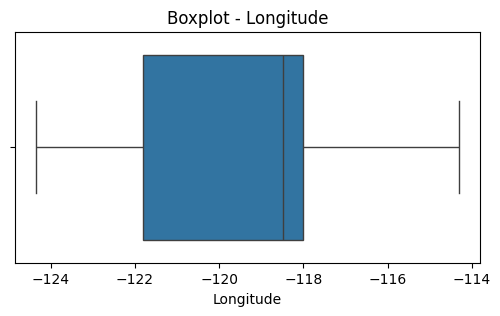

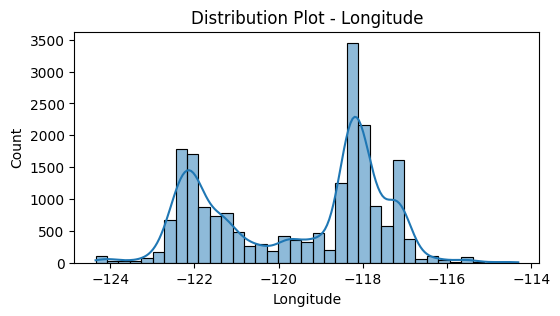


Scaled Dataset
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.197582  0.982143  1.088935  -0.267221   -0.899787 -0.307981  1.052548   
1  2.186664 -0.607019  0.626066  -0.822926    1.316631 -0.830800  1.043185   
2  1.707732  1.856182  1.898042   0.263955   -0.714286 -0.018599  1.038503   
3  0.967177  1.856182  0.364978   0.259814   -0.648188 -0.316908  1.038503   
4  0.142854  1.856182  0.653191   0.345657   -0.640725 -0.746784  1.038503   

   Longitude  
0  -1.327835  
1  -1.322844  
2  -1.332827  
3  -1.337818  
4  -1.337818  


In [ ]:
for col in numerical_cols:

    print("\n" + "="*50)
    print(f"Column : {col}")

    # ----------------------------------------
    # Skewness
    # ----------------------------------------
    skewness = df[col].skew()
    print(f"Skewness : {round(skewness, 3)}")

    # ----------------------------------------
    # IQR Outlier Detection
    # ----------------------------------------
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"Outliers : {len(outliers)}")

    # ----------------------------------------
    # Decide Scaling Method
    # ----------------------------------------
    if len(outliers) > 0:
        scaler_name = "RobustScaler"

    elif -0.5 <= skewness <= 0.5:
        scaler_name = "StandardScaler"

    else:
        scaler_name = "MinMaxScaler"

    print(f"Recommended Scaling : {scaler_name}")

    # ----------------------------------------
    # Boxplot
    # ----------------------------------------
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

    # ----------------------------------------
    # Histogram
    # ----------------------------------------
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution Plot - {col}")
    plt.show()

# ============================================
# Apply Scaling
# ============================================

scaled_df = df.copy()

for col in numerical_cols:

    skewness = df[col].skew()

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    # ----------------------------------------
    # Choose scaler
    # ----------------------------------------
    if len(outliers) > 0:

        scaler = RobustScaler()

    elif -0.5 <= skewness <= 0.5:

        scaler = StandardScaler()

    else:

        scaler = MinMaxScaler()

    # ----------------------------------------
    # Scale column
    # ----------------------------------------
    scaled_df[col] = scaler.fit_transform(
        df[[col]]
    )

# ============================================
# Final Scaled Dataset
# ============================================

print("\nScaled Dataset")
print(scaled_df.head())

In [ ]:
scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.197582,0.982143,1.088935,-0.267221,-0.899787,-0.307981,1.052548,-1.327835
1,2.186664,-0.607019,0.626066,-0.822926,1.316631,-0.830800,1.043185,-1.322844
2,1.707732,1.856182,1.898042,0.263955,-0.714286,-0.018599,1.038503,-1.332827
3,0.967177,1.856182,0.364978,0.259814,-0.648188,-0.316908,1.038503,-1.337818
4,0.142854,1.856182,0.653191,0.345657,-0.640725,-0.746784,1.038503,-1.337818


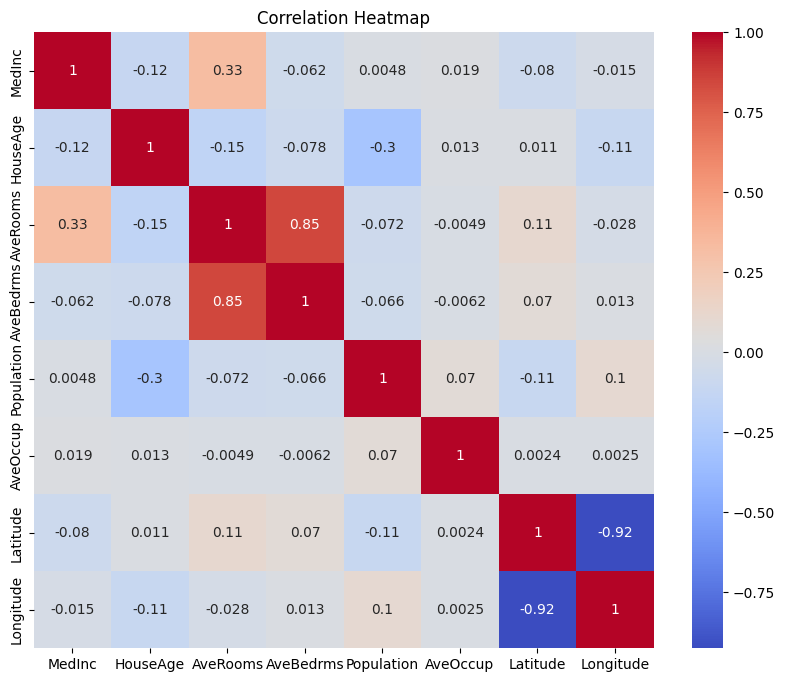

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = scaled_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.datasets import fetch_california_housing

# Load dataset
housing = fetch_california_housing()

# Add target column
scaled_df["Price"] = housing.target

In [ ]:
corr_matrix = scaled_df.corr()

price_corr = corr_matrix["Price"].sort_values(
    ascending=False
)

print(price_corr)

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64


In [ ]:
# Remove weak features

scaled_df = scaled_df.drop(
    columns=[
        'AveOccup',
        'Population',
        'Longitude',
        'AveBedrms'
    ]
)

# Check remaining columns
print(scaled_df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'Latitude', 'Price'], dtype='object')


In [ ]:
# Features
X = scaled_df.drop("Price", axis=1)

# Target
y = scaled_df["Price"]

print(X.head())
print(y.head())

     MedInc  HouseAge  AveRooms  Latitude
0  2.197582  0.982143  1.088935  1.052548
1  2.186664 -0.607019  0.626066  1.043185
2  1.707732  1.856182  1.898042  1.038503
3  0.967177  1.856182  0.364978  1.038503
4  0.142854  1.856182  0.653191  1.038503
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


# Train, Test and Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

# First split:
# 80% Train
# 20% Temporary

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Second split:
# 10% Validation
# 10% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

# ============================================
# Shapes
# ============================================

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_val.shape)
print("Testing Shape :", X_test.shape)


Training Shape : (16512, 4)
Validation Shape : (2064, 4)
Testing Shape : (2064, 4)


Train the Linear Regression Model

In [ ]:

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# ============================================
# STEP 4 : Predictions
# ============================================

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Evaluations

In [ ]:
# --------------------------------------------
# TRAIN METRICS
# --------------------------------------------

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

# --------------------------------------------
# VALIDATION METRICS
# --------------------------------------------

val_mae = mean_absolute_error(
    y_val,
    y_val_pred
)

val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_val_pred
    )
)

val_r2 = r2_score(
    y_val,
    y_val_pred
)

# --------------------------------------------
# TEST METRICS
# --------------------------------------------

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

# ============================================
# Print Results
# ============================================

print("\n========== TRAIN METRICS ==========")
print("MAE :", train_mae)
print("RMSE :", train_rmse)
print("R2 Score :", train_r2)

print("\n========== VALIDATION METRICS ==========")
print("MAE :", val_mae)
print("RMSE :", val_rmse)
print("R2 Score :", val_r2)

print("\n========== TEST METRICS ==========")
print("MAE :", test_mae)
print("RMSE :", test_rmse)
print("R2 Score :", test_r2)


========== TRAIN METRICS ==========
MAE : 0.5948183553093371
RMSE : 0.7989089953528047
R2 Score : 0.5225419016956813

========== VALIDATION METRICS ==========
MAE : 0.6012101666405003
RMSE : 0.8089100743118618
R2 Score : 0.5030736943625713

========== TEST METRICS ==========
MAE : 0.5975725430850177
RMSE : 0.8029692332038031
R2 Score : 0.5053126527787137


# Coefficients

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nFeature Coefficients")
print(coefficients)



Feature Coefficients
    Feature  Coefficient
0    MedInc     0.955425
1  HouseAge     0.213327
2  AveRooms    -0.035190
3  Latitude    -0.096738


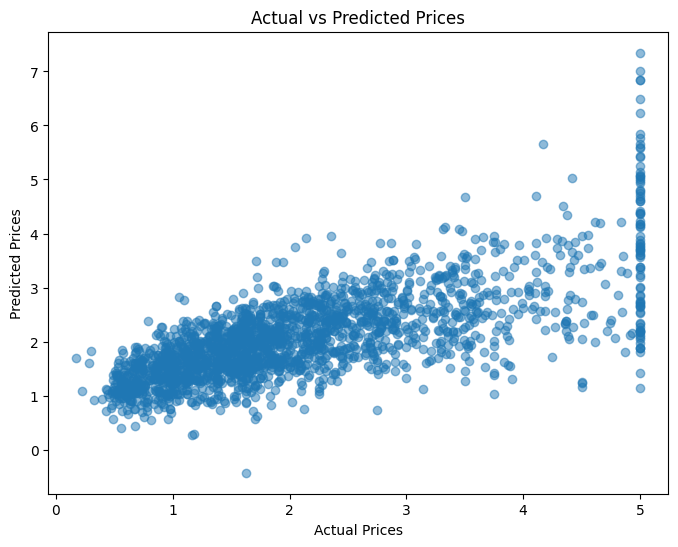

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [ ]:
# Take some real test samples
sample_data = X_test.iloc[:5]

# Actual prices
actual_prices = y_test.iloc[:5]

# Predict prices
predicted_prices = model.predict(sample_data)

# ============================================
# Compare Actual vs Predicted
# ============================================

comparison = pd.DataFrame({
    "Actual Price": actual_prices.values,
    "Predicted Price": predicted_prices
})

print(comparison)

   Actual Price  Predicted Price
0         2.385         1.778757
1         3.297         2.010761
2         0.952         1.949480
3         2.451         2.162386
4         0.641         1.078215
